# Denoising comparison

In [26]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
from bm4d import bm4d, BM4DStages
import pickle
import copy
import time
import humanfriendly
from skimage.restoration import estimate_sigma
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [43]:
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_ref = pickle.load(file)

tile_ref.apply("crop", parameters = {"crop_idx": (slice(50,tile_ref.EDX_dim[0]-50),slice(50,tile_ref.EDX_dim[1]-50),slice(None,None,None))})
tile_ref.apply("binning", parameters={"dim": (974,974,250)})
#tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})


with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned_20frames.pkl', 'rb') as file:
    tile = pickle.load(file)

tile.apply("crop", parameters = {"crop_idx": (slice(50,tile.EDX_dim[0]-50),slice(50,tile.EDX_dim[1]-50),slice(None,None,None))})
tile.apply("binning", parameters={"dim": (974,974,250)})

tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None


In [44]:
psnr_list = eval_psnr(MinMax(tile.EDX.astype('float32')),MinMax(tile_ref.EDX.astype('float32')))

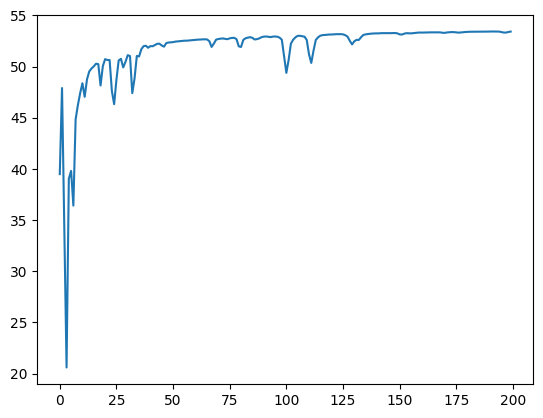

In [45]:
plt.plot(psnr_list[:200])

52.08388895194837
